# EDA del objetivo: fórmula del profesor

Ejecutar todas las celdas recalcula el EDA únicamente sobre DEVELOPMENT. El código fuente reside en `src/08_eda_target_development.py`; el informe se sincroniza desde las tablas mediante `src/08_render_target_report.py`. La interpretación guardada corresponde al snapshot de datos documentado.


In [1]:
from pathlib import Path
import runpy
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p/'src/08_eda_target_development.py').is_file())
runpy.run_path(str(ROOT/'src/08_eda_target_development.py'), run_name='__main__')
report = runpy.run_path(str(ROOT/'src/08_render_target_report.py'))
report['render'](write_notebook=False)


COBERTURA
  symbol  observed  valid  boundary  missing_window  irregular_window
BTCUSDT     42833  42539        24             240                30
ETHUSDT     42833  42539        24             240                30
BNBUSDT     42833  42539        24             240                30
XRPUSDT     42833  42564        24             240                 5
SOLUSDT     42833  42564        24             240                 5

RESUMEN
              n       min        q1    median      mean        q3       p95       p99       max       std      skew  excess_kurtosis  zero     lower     upper  iqr_flagged  iqr_percent  log_skew  log_excess_kurtosis    acf_1h   acf_24h
symbol                                                                                                                                                                                                                                    
BTCUSDT  42539  0.044503  0.333471  0.485389  0.550719  0.673761  1.181821  1.774787  3.376542 

Informe 2.1, rango del objetivo y presentación sincronizados.


# 2. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio utiliza exclusivamente DEVELOPMENT, del 11 de agosto de 2020 a las 06:00 UTC al 1 de julio de 2025 a las 18:00 UTC. TEST permanece reservado desde la partición cronológica inicial. Los resultados describen los datos disponibles para desarrollar el modelo; no se entrenan modelos ni se evalúa el conjunto de prueba.

Las decisiones posteriores de imputación, transformación, escalado, selección de variables o tratamiento de extremos deberán ajustarse únicamente con la porción de entrenamiento de cada partición temporal. Las estadísticas globales de DEVELOPMENT que se presentan aquí son descriptivas y no constituyen parámetros de preprocesamiento para validación.

## 2.1 Análisis de la variable objetivo

### 2.1.1 Definición y disponibilidad temporal

La variable objetivo es la **desviación estándar de los retornos horarios de las próximas 24 horas**, una magnitud continua. Se adopta la fórmula de volatilidad del profesor, adaptando la frecuencia de días a horas y fijando una ventana de 24 retornos. No es la volatilidad acumulada del retorno de un día.

Sea $C_{i,s}$ el cierre de la vela del activo $i$ cuya apertura UTC es $s$. Se define:

$$
r_{i,s}=\ln\left(\frac{C_{i,s}}{C_{i,s-1}}\right),\qquad
\bar r^+_{i,s}=\frac1{24}\sum_{j=1}^{24}r_{i,s+j},
$$

$$
\boxed{y_{i,s}=100\sqrt{\frac1{24}\sum_{j=1}^{24}(r_{i,s+j}-\bar r^+_{i,s})^2}}.
$$

El divisor es **24**, no 23: se utiliza `ddof=0`. El factor 100 expresa el resultado en porcentaje; no se anualiza ni se multiplica por $\sqrt{24}$. Esta es la misma definición y escala del objetivo de las secciones 2.3 y 3.

La predicción se emite **después del cierre de la vela ancla $s$ y una vez disponible ese cierre**, alrededor de $s+1$ hora. El objetivo utiliza los retornos $r_{i,s+1},\ldots,r_{i,s+24}$, construidos a partir de los 25 cierres $C_{i,s},\ldots,C_{i,s+24}$. Solo se conoce después del cierre de la última vela del horizonte, alrededor de $s+25$ horas. Por ejemplo, para el ancla de apertura 10:00 se predice alrededor de las 11:00 y se evalúan los 24 retornos posteriores. No se predice a la apertura de la vela ancla usando su cierre futuro.

En la notación del profesor, $\sigma_t$ usa los retornos $r_{t-24},\ldots,r_{t-1}$. Con $t=s+1$, la referencia histórica disponible es $\sigma_{s+1}$ y el objetivo aquí almacenado es $y_{i,s}=100\sigma_{i,s+25}$. Así se reconcilia la notación de la fórmula con el índice `open_time` del código sin desplazar las observaciones una hora por error.

Las frecuencias y el desbalance de clases no aplican: el problema es de regresión temporal. Las variables explicativas utilizan únicamente la vela ya cerrada o información anterior.

### 2.1.2 Ventanas válidas y cobertura

Se exige una secuencia de 25 cierres horarios consecutivos para calcular los 24 retornos. Cada cierre debe corresponder al último milisegundo de su hora, según la regla de consistencia definida en 1.7.6. Las ventanas que incluyen horas ausentes o alguno de los 28 cierres no convencionales quedan sin objetivo en esta definición conservadora. Esta exclusión afecta a la tabla derivada, no elimina filas del dataset original ni declara erróneas las velas señaladas.

También se excluyen las últimas 24 horas de referencia de DEVELOPMENT, porque su horizonte futuro sobrepasa la partición. No se consultan datos de TEST para completarlo. Los motivos se contabilizan de forma excluyente: primero límite temporal, después horas ausentes y finalmente cierres irregulares.

| Activo | Velas observadas | Objetivos válidos | Borde final | Huecos | Cierres irregulares |
| --- | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| ETHUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| BNBUSDT | 42,833 | 42,539 | 24 | 240 | 30 |
| XRPUSDT | 42,833 | 42,564 | 24 | 240 | 5 |
| SOLUSDT | 42,833 | 42,564 | 24 | 240 | 5 |

En total se obtienen **212,745 objetivos válidos**; 1,420 velas de referencia quedan sin objetivo: 120 por el borde final, 1,200 por huecos y 100 adicionales por cierres irregulares. Una misma vela irregular afecta a varias ventanas solapadas.

Como sensibilidad, aceptar cierres irregulares manteniendo las demás condiciones produciría 42,569 objetivos por activo. Añadiría 30 ventanas en BTC, ETH y BNB, y 5 en XRP y SOL. La diferencia absoluta máxima entre las medias estricta y relajada es 0.000121 puntos porcentuales; los máximos no cambian. Se mantiene la regla conservadora por consistencia temporal, no porque esta sensibilidad demuestre la validez de los cierres irregulares. Véase la [tabla de sensibilidad](../outputs/tables/eda_target_sensitivity.csv).

### 2.1.3 Distribución, asimetría y valores extremos

| Activo | Mínimo (%) | Mediana (%) | Media (%) | P95 (%) | P99 (%) | Máximo (%) |
| --- | --- | --- | --- | --- | --- | --- |
| BTCUSDT | 0.0445 | 0.4854 | 0.5507 | 1.1818 | 1.7748 | 3.3765 |
| ETHUSDT | 0.0542 | 0.6196 | 0.7129 | 1.5124 | 2.4151 | 5.1053 |
| BNBUSDT | 0.0787 | 0.5589 | 0.6875 | 1.5804 | 2.6840 | 5.9566 |
| XRPUSDT | 0.1144 | 0.6767 | 0.8756 | 2.1890 | 3.6531 | 7.9232 |
| SOLUSDT | 0.1853 | 0.9605 | 1.1413 | 2.4680 | 3.9244 | 7.0645 |

No se observan objetivos iguales a cero. SOL presenta la mayor mediana (0.9605%) y BTC la menor (0.4854%). XRP alcanza el máximo más alto (7.9232%), aunque su mediana es inferior a la de SOL. El nivel habitual y la intensidad de los episodios extremos deben distinguirse. Los cuartiles y la desviación estándar están en el [resumen completo](../outputs/tables/eda_target_summary.csv). Las pequeñas diferencias de XRP y SOL respecto de 2.3.4 obedecen a que aquí se usan todas las etiquetas válidas de cada activo y allí la intersección de timestamps de los cinco.



| Activo | Asimetría | Exceso de curtosis | Señalados por IQR | Porcentaje |
| --- | --- | --- | --- | --- |
| BTCUSDT | 2.036 | 7.440 | 2,109 | 4.96% |
| ETHUSDT | 2.228 | 9.064 | 2,006 | 4.72% |
| BNBUSDT | 3.221 | 17.822 | 2,467 | 5.80% |
| XRPUSDT | 3.162 | 15.250 | 3,242 | 7.62% |
| SOLUSDT | 2.608 | 10.972 | 2,294 | 5.39% |

La asimetría es positiva en todos los activos y la media supera la mediana. El exceso de curtosis va de 7.440 a 17.822, compatible con colas empíricas pronunciadas respecto de una referencia normal. No demuestra una ley de colas ni independencia. BNB y XRP presentan los mayores excesos de curtosis; XRP tiene la mayor proporción señalada por IQR.

Los valores fuera de las cercas $Q_1-1.5\,IQR$ y $Q_3+1.5\,IQR$ son candidatos a extremos, no errores demostrados. Se conservan todos los objetivos válidos, incluidos los elevados. El IQR no se utiliza aquí para recortar ni winsorizar la variable objetivo.

### 2.1.4 Necesidad de transformación

El logaritmo permite examinar si la escala positiva y la asimetría del objetivo se representan de forma más equilibrada. La tabla compara la asimetría y el exceso de curtosis antes y después del logaritmo, únicamente como diagnóstico.

| Activo | Asimetría original | Asimetría de ln(y) | Exceso de curtosis original | Exceso de curtosis de ln(y) |
| --- | --- | --- | --- | --- |
| BTCUSDT | 2.036 | -0.271 | 7.440 | 0.580 |
| ETHUSDT | 2.228 | -0.126 | 9.064 | 0.437 |
| BNBUSDT | 3.221 | 0.175 | 17.822 | 0.257 |
| XRPUSDT | 3.162 | 0.454 | 15.250 | 0.356 |
| SOLUSDT | 2.608 | 0.313 | 10.972 | 0.283 |

Una menor asimetría no demuestra normalidad ni garantiza mejores pronósticos. No se adopta una transformación definitiva. Box–Cox es una alternativa para valores estrictamente positivos, pero su parámetro no se estima globalmente en esta etapa: si se evalúa posteriormente, deberá ajustarse dentro de cada partición de entrenamiento. Lo mismo aplica a cualquier desplazamiento utilizado si aparecen ceros en datos futuros.

Si se modelara el logaritmo del objetivo, minimizar el error en esa escala cambiaría la importancia relativa de los errores grandes y pequeños. Además, exponenciar un pronóstico en escala logarítmica no produce automáticamente la media condicional en la escala original. La elección deberá evaluarse cronológicamente y las métricas finales deberán incluir la escala original.

### 2.1.5 Comportamiento temporal



| Activo | Apertura de referencia (UTC) | Máximo (%) |
| --- | --- | --- |
| BTCUSDT | 2021-05-19 06:00 | 3.3765 |
| ETHUSDT | 2021-05-19 09:00 | 5.1053 |
| BNBUSDT | 2021-05-19 03:00 | 5.9566 |
| XRPUSDT | 2021-02-01 02:00 | 7.9232 |
| SOLUSDT | 2022-11-09 14:00 | 7.0645 |

Los máximos de BTC, ETH y BNB corresponden a ventanas iniciadas el 19 de mayo de 2021; los de XRP y SOL ocurren en fechas diferentes. Las fechas identifican ventanas futuras de 24 horas y no un único retorno ni una causa económica comprobada. La evolución muestra episodios de distinta intensidad, lo que exige evaluar el desempeño en varios bloques cronológicos.

| Activo | Correlación del objetivo a 1h | Correlación del objetivo a 24h |
| --- | --- | --- |
| BTCUSDT | 0.989 | 0.596 |
| ETHUSDT | 0.991 | 0.649 |
| BNBUSDT | 0.993 | 0.709 |
| XRPUSDT | 0.991 | 0.625 |
| SOLUSDT | 0.992 | 0.687 |

Las correlaciones se calculan por pares disponibles sobre la cuadrícula horaria, sin comprimir los huecos. La elevada asociación a una hora está influida mecánicamente por el solapamiento de 23 retornos entre etiquetas. A 24 horas las ventanas de retornos ya no se solapan, aunque persiste asociación descriptiva. Ninguno de estos coeficientes sustituye una evaluación fuera de muestra.

No se realiza análisis espacial: el dataset carece de coordenadas geográficas. Los activos son entidades del panel y no ubicaciones espaciales.

### 2.1.6 Relación con las variables explicativas disponibles

Como exploración inicial se compara el objetivo con las nueve variables numéricas de la vela cerrada, el retorno de esa hora y la volatilidad pasada $100\,\operatorname{std}(r_{i,s-23},\ldots,r_{i,s};\mathrm{ddof}=0)$. Esta última centra los retornos en su media, utiliza divisor 24 y requiere 25 cierres consecutivos convencionales. Es la referencia disponible de Persistence en la sección 3; aquí solo se estudia su asociación, sin evaluar pronósticos.

Las fechas actúan como índices temporales y `symbol` identifica el activo. No se asignan códigos numéricos arbitrarios a los símbolos para calcular correlaciones. Las asociaciones se calculan por activo y con los pares disponibles para cada variable; por eso su tamaño de muestra puede variar. Las cifras completas se incluyen en la [tabla de correlaciones y tamaños de muestra](../outputs/tables/eda_target_correlations.csv).





La volatilidad pasada de 24 horas muestra correlaciones de Pearson entre 0.596 y 0.709, y de Spearman entre 0.582 y 0.697. Sus retornos no se solapan con los futuros, aunque comparten el cierre de frontera. La asociación motiva la referencia Persistence, cuyo desempeño se evalúa separadamente en la sección 3.

El volumen en USDT presenta asociaciones Spearman distintas por activo (BTCUSDT: 0.387, ETHUSDT: 0.505, BNBUSDT: 0.531, XRPUSDT: 0.565, SOLUSDT: 0.030). Para el número de operaciones, Spearman va de 0.007 a 0.541. Estas diferencias no establecen utilidad predictiva fuera de muestra; las asociaciones de todos los campos de volumen se conservan en la tabla completa.

Los precios OHLC tienen asociaciones descriptivas que pueden reflejar tendencias y regímenes; no se interpretan como causalidad. El retorno horario con signo presenta Pearson entre -0.041 y 0.002. Su asociación lineal pequeña no descarta relaciones no lineales ni relaciones con su magnitud absoluta. Los diagramas muestran dispersión y extremos que un coeficiente aislado no resume.

Estos resultados no constituyen una selección definitiva de predictores ni un análisis multivariado condicional. Las asociaciones con precios y volúmenes pueden depender del periodo y de cambios de régimen; una correlación no implica causalidad ni capacidad predictiva fuera de muestra. La selección y las transformaciones deberán contrastarse después mediante validación temporal, sin TEST.

### 2.1.7 Implicaciones para métricas y validación

Las métricas comunes son RMSE, MAPE y $R^2$; MAE es complementaria. RMSE y MAE se expresan en puntos porcentuales de volatilidad, MAPE en porcentaje y $R^2$ es adimensional. Se reportan por activo y fold antes del promedio con pesos iguales. MAPE es indefinido con objetivos cero y sensible a valores cercanos a cero; no se añaden denominadores artificiales. $R^2$ requiere variabilidad del objetivo. Esta sección describe el objetivo; las métricas predictivas se presentan en la sección 3.

La validación deberá ser cronológica, con ventanas de entrenamiento anteriores a las de validación, y mantener todos los activos de una misma fecha en el mismo bloque temporal. No se utilizará una partición aleatoria de filas. La [documentación de validación temporal de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) describe la separación ordenada y el uso de un intervalo entre entrenamiento y evaluación; en este panel, ese intervalo debe aplicarse a timestamps globales, no a un número de filas mezcladas entre activos.

Los objetivos de horas consecutivas comparten 23 de sus 24 retornos. Por ello, la dependencia entre etiquetas no puede interpretarse como evidencia automática de capacidad predictiva y el número de filas no equivale a observaciones independientes. En cada frontera se excluirán del entrenamiento las etiquetas cuyo horizonte alcance el inicio de la validación: una separación conservadora de 24 horas entre las horas de referencia evita el solapamiento de retornos futuros. Además, toda etiqueta de entrenamiento debe estar disponible antes de realizar la primera predicción de validación. Las ventanas se comprobarán por tiempo real, especialmente alrededor de huecos.

Todos los parámetros aprendidos de los datos deberán ajustarse de nuevo dentro de cada entrenamiento. TEST se mantendrá reservado para la evaluación final del procedimiento ya fijado.

### 2.1.8 Reproducibilidad

El cálculo está en `src/08_eda_target_development.py`; `src/08_render_target_report.py` sincroniza estas tablas e interpretaciones con los resultados guardados. Ejecutar ambos scripts en ese orden desde el entorno de `requirements.txt`. Los resultados y metadatos se guardan en `outputs/tables/eda_target_*`; la tabla derivada permanece separada de los datos originales. Cada objetivo válido se contrasta con el cálculo directo centrado de sus 24 retornos, con divisor 24; se verifica el borde de DEVELOPMENT y su SHA-256. El notebook ejecuta el cálculo y muestra las cuatro figuras. No se consulta TEST ni se reentrenan modelos para esta corrección.




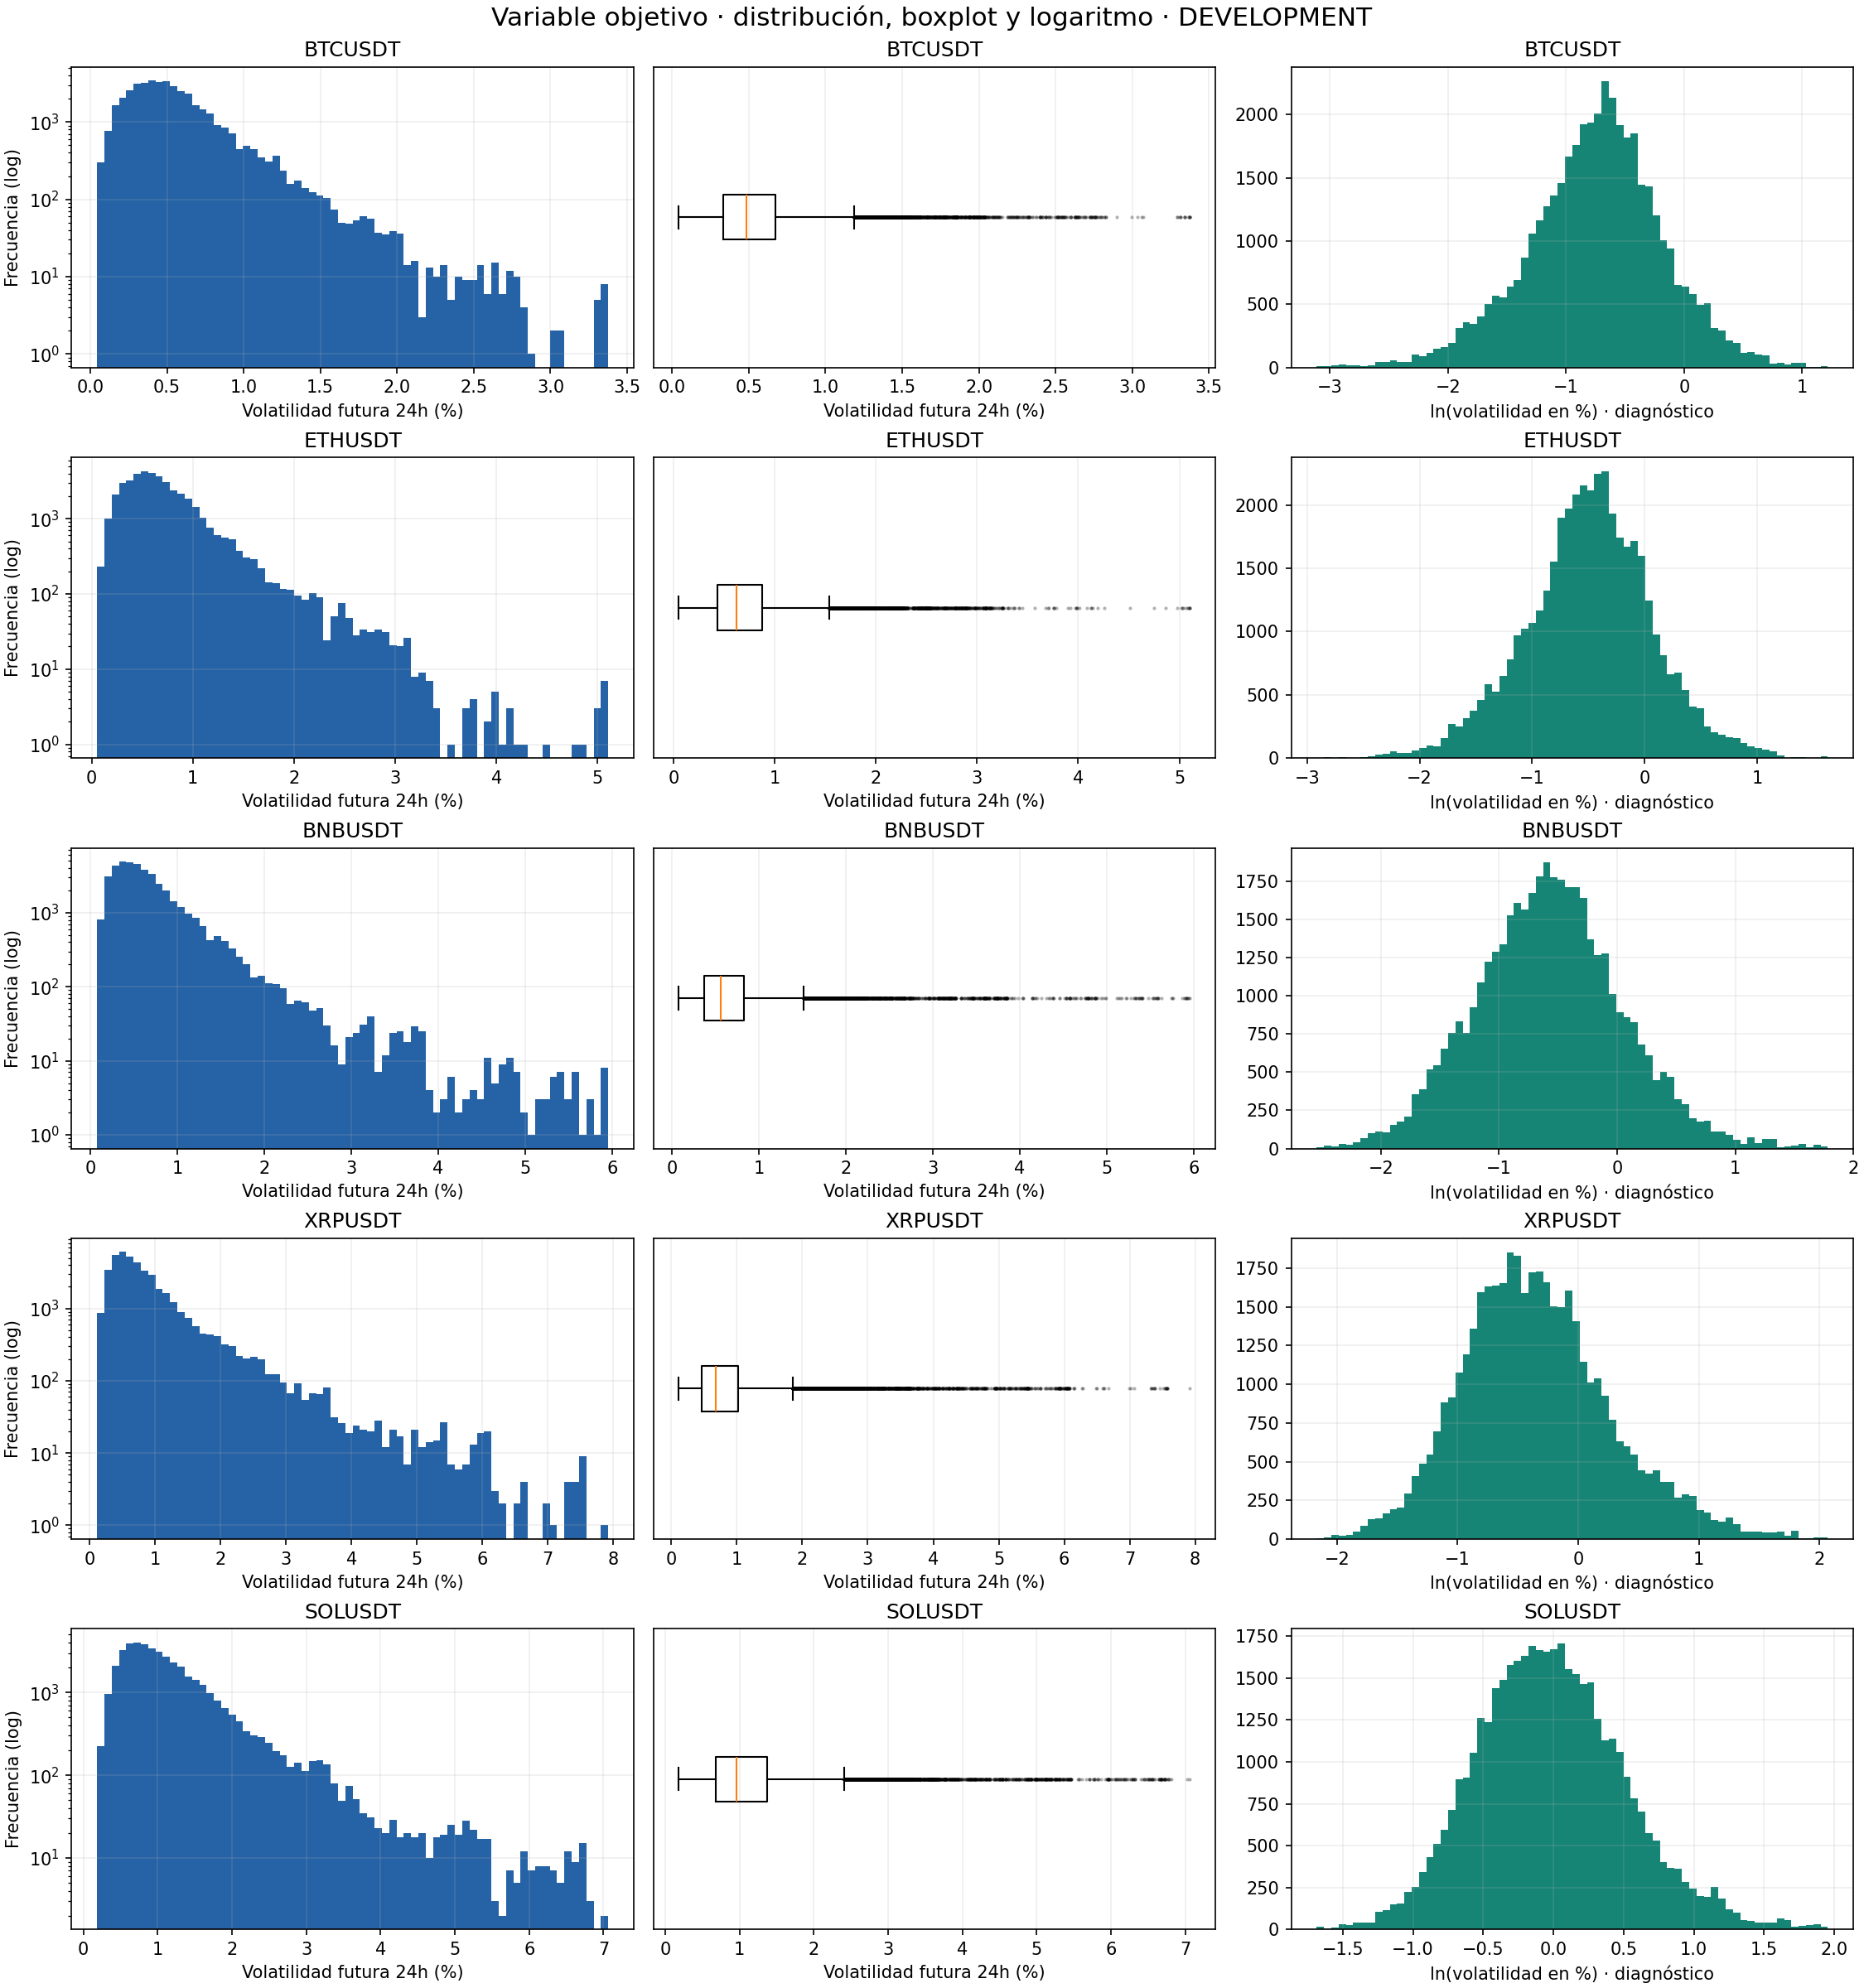

In [2]:
display(Image(filename=str(ROOT/'book/_static/figures/eda_target_distribution.png')))

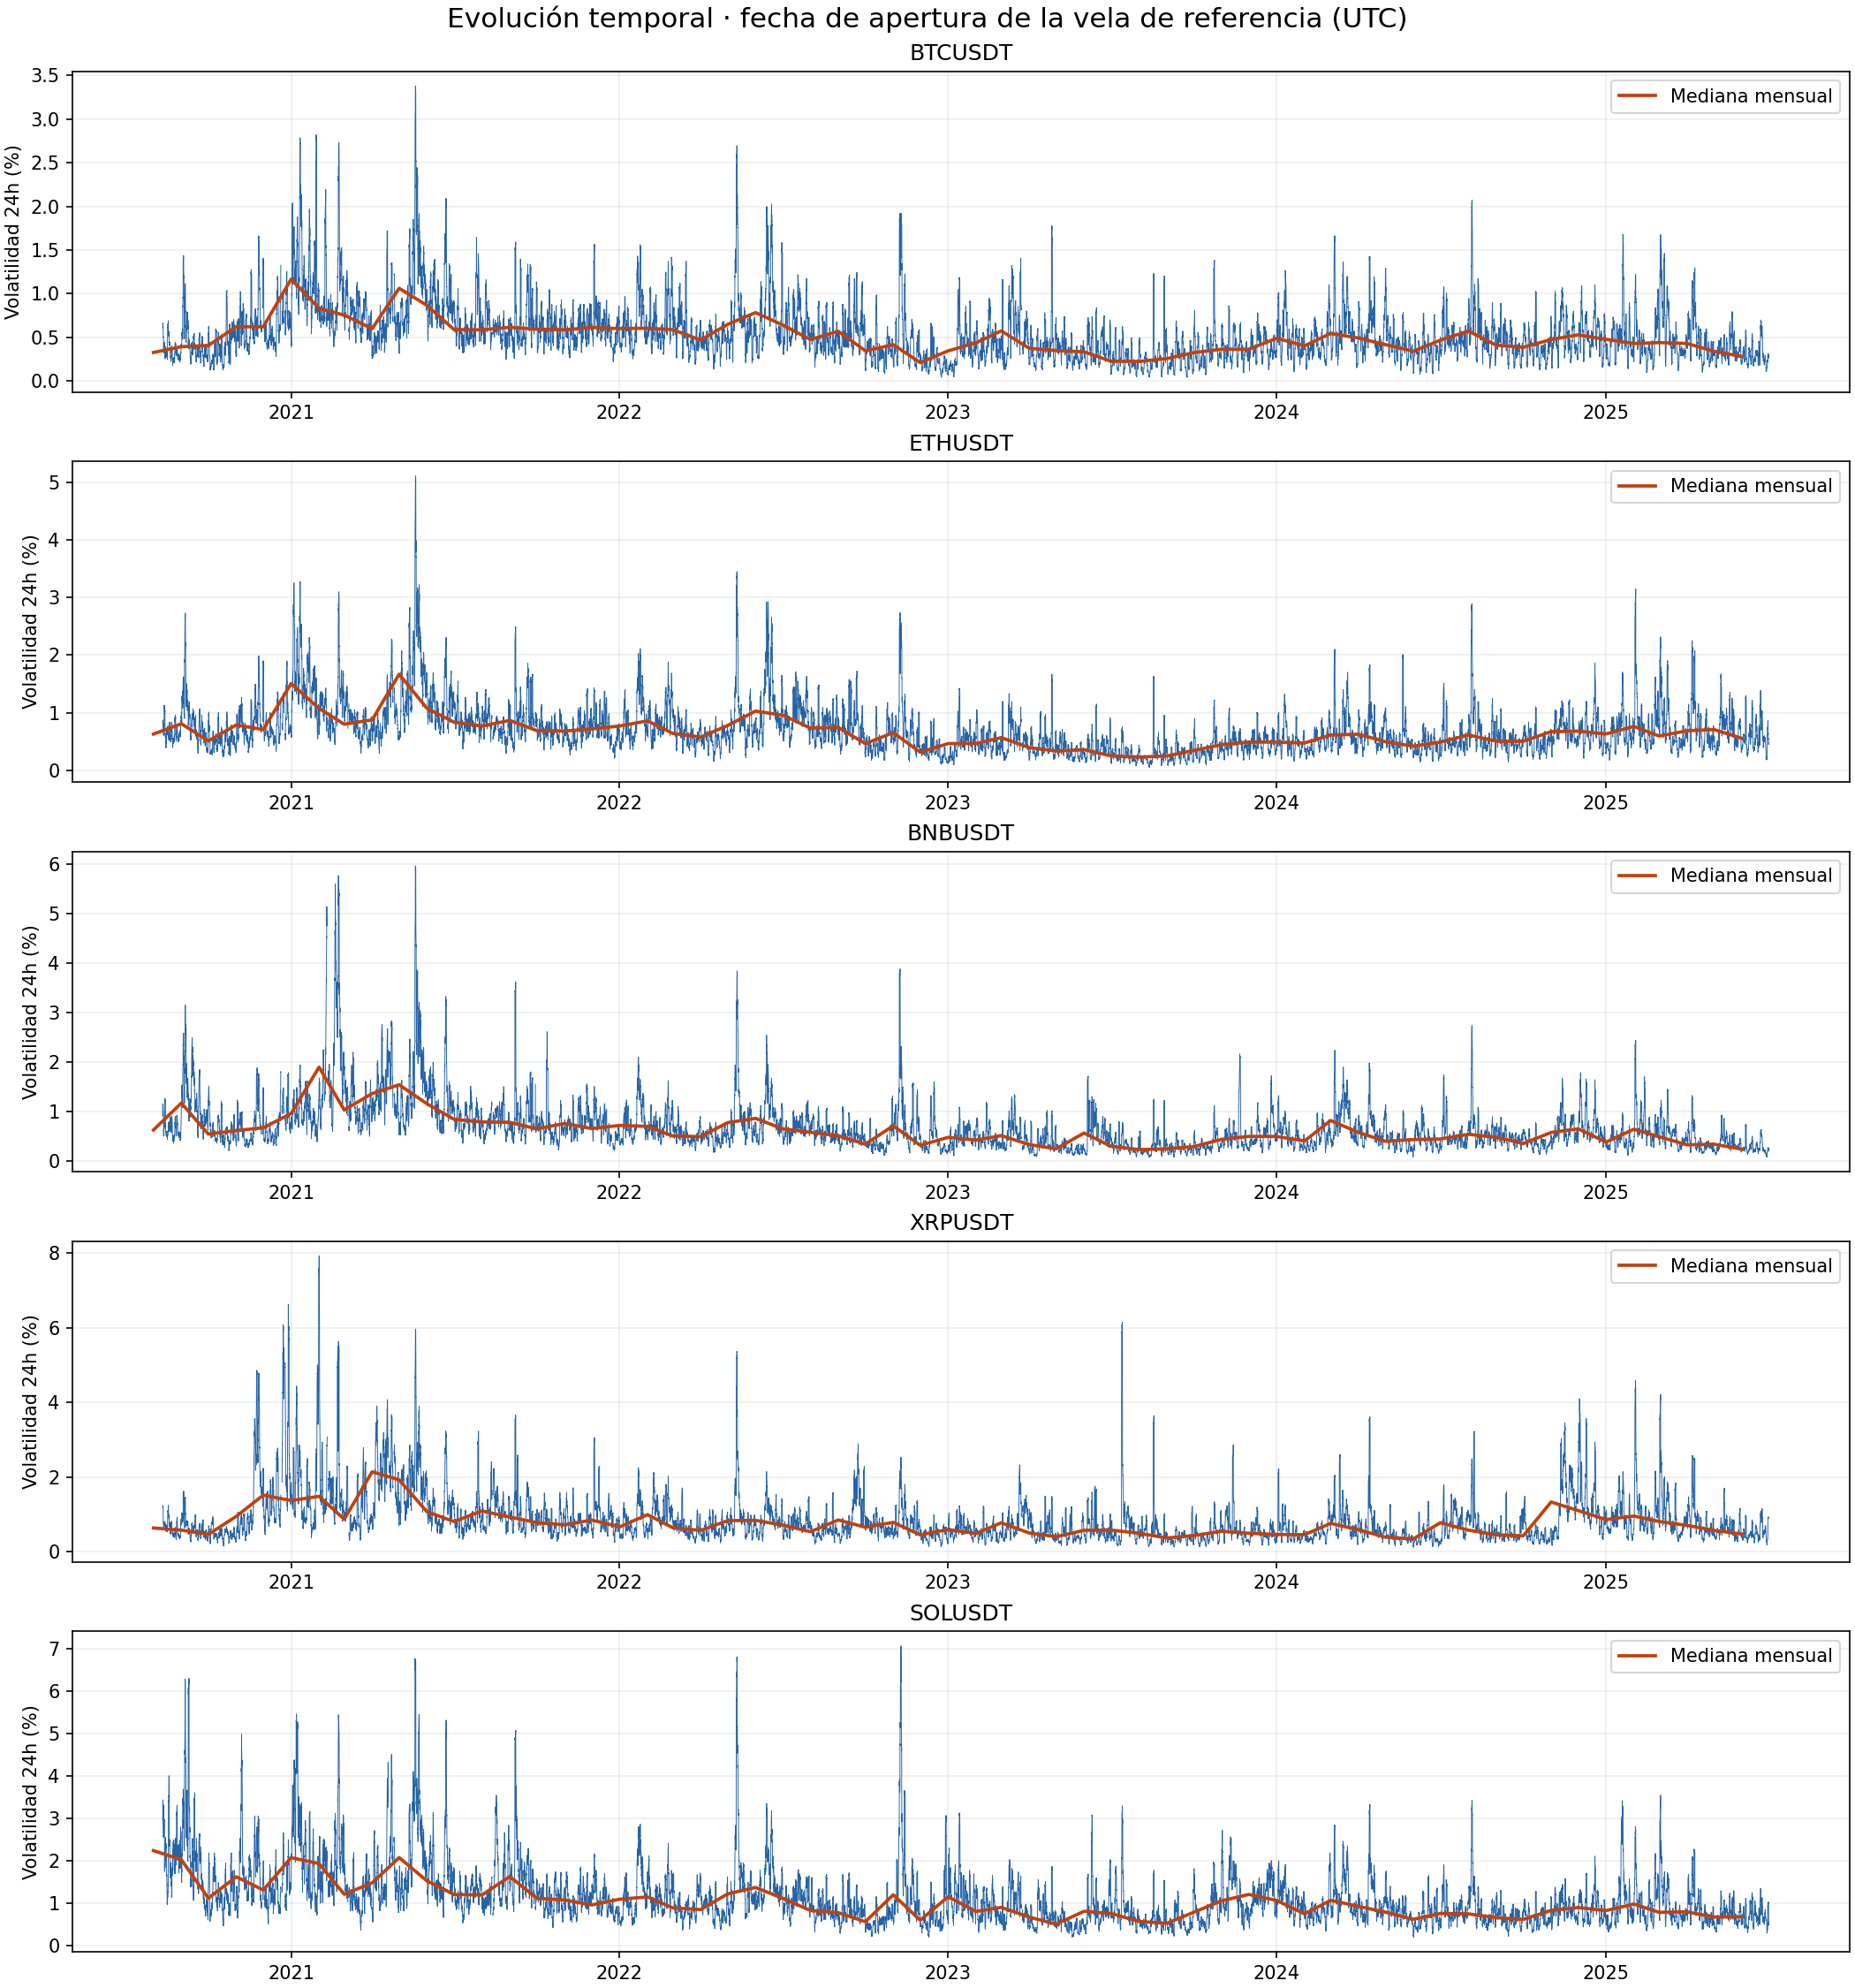

In [3]:
display(Image(filename=str(ROOT/'book/_static/figures/eda_target_time.png')))

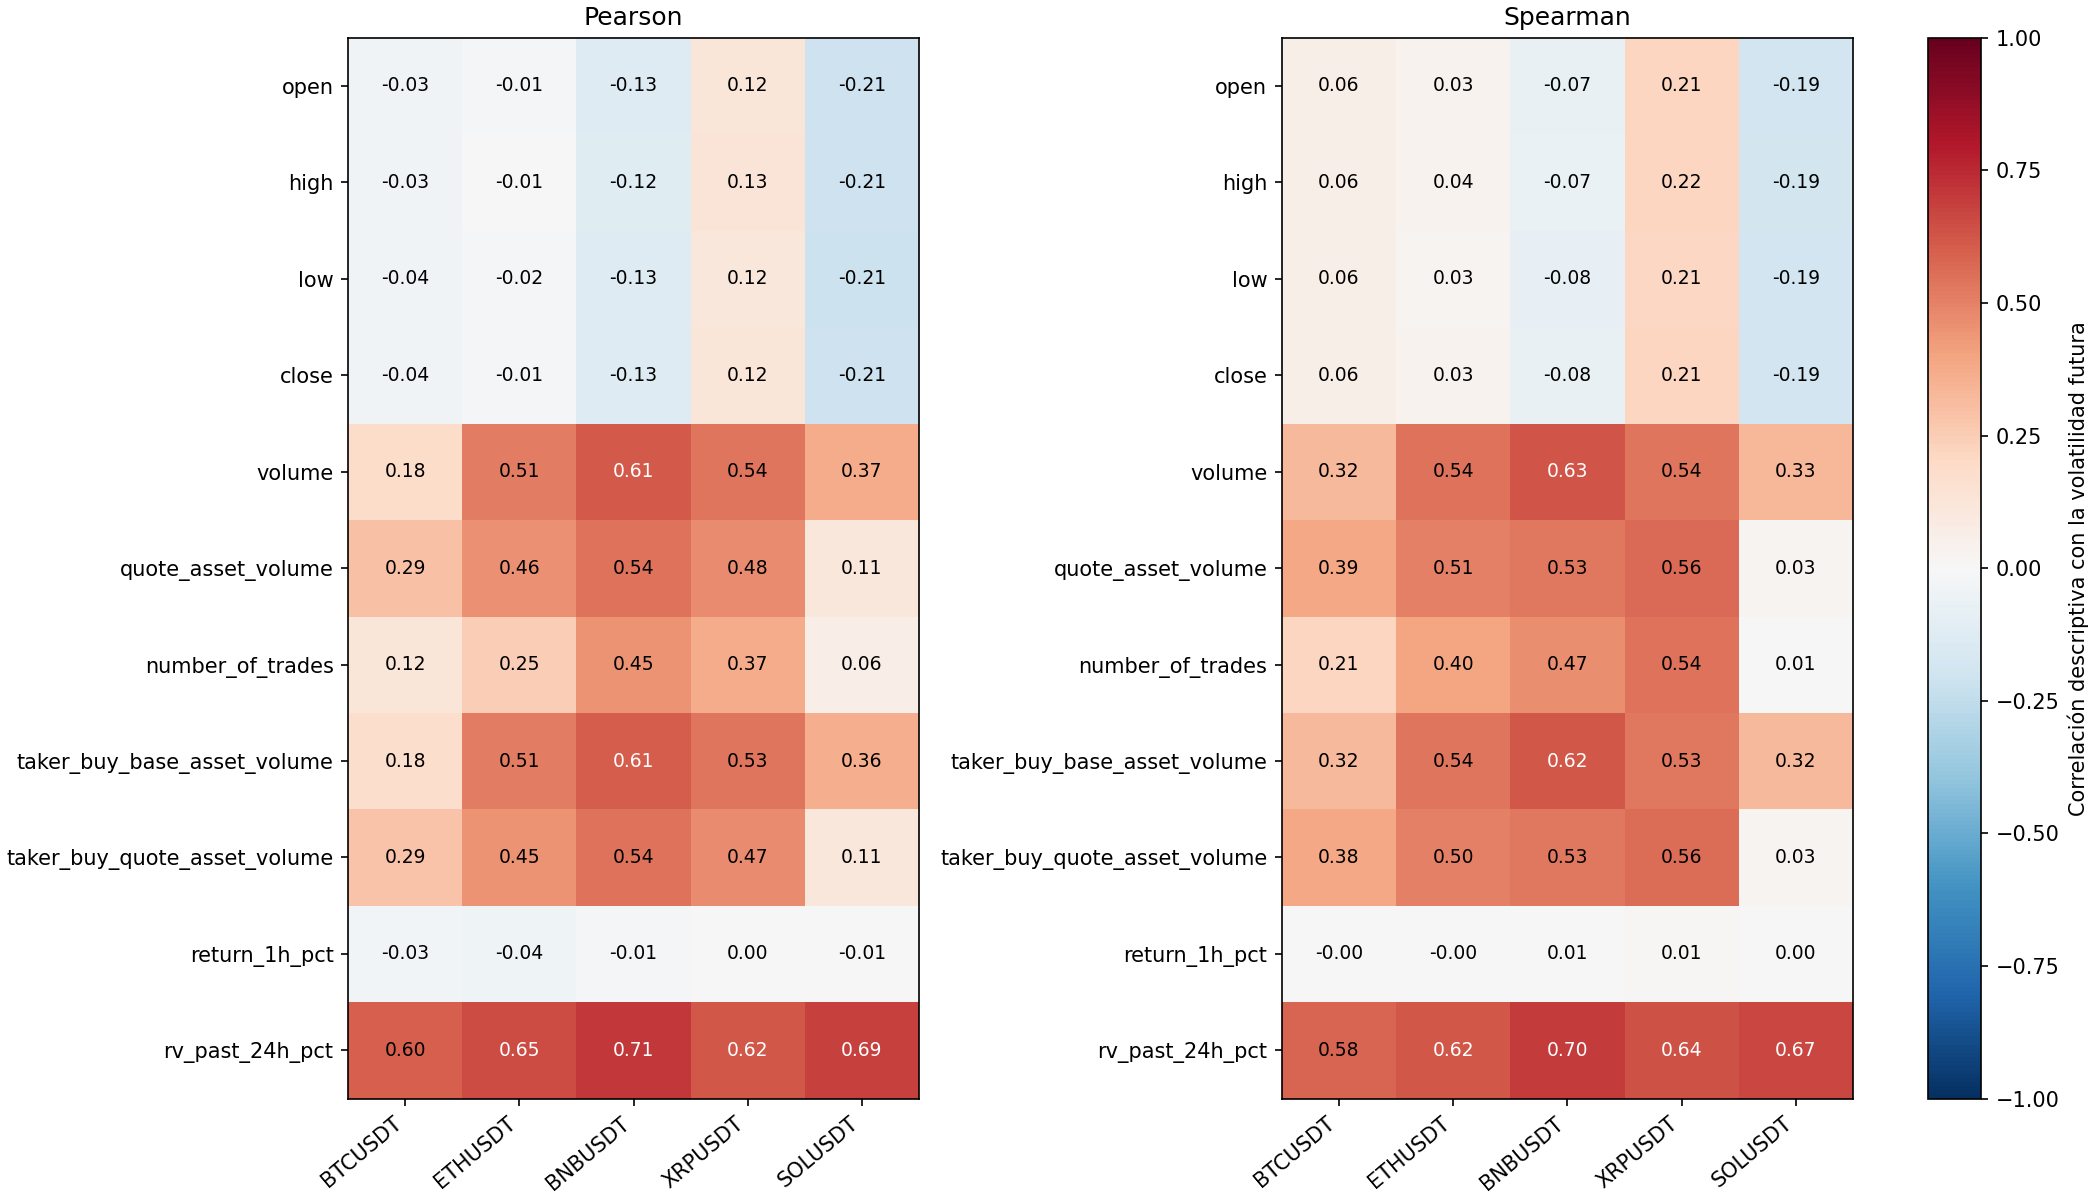

In [4]:
display(Image(filename=str(ROOT/'book/_static/figures/eda_target_correlations.png')))

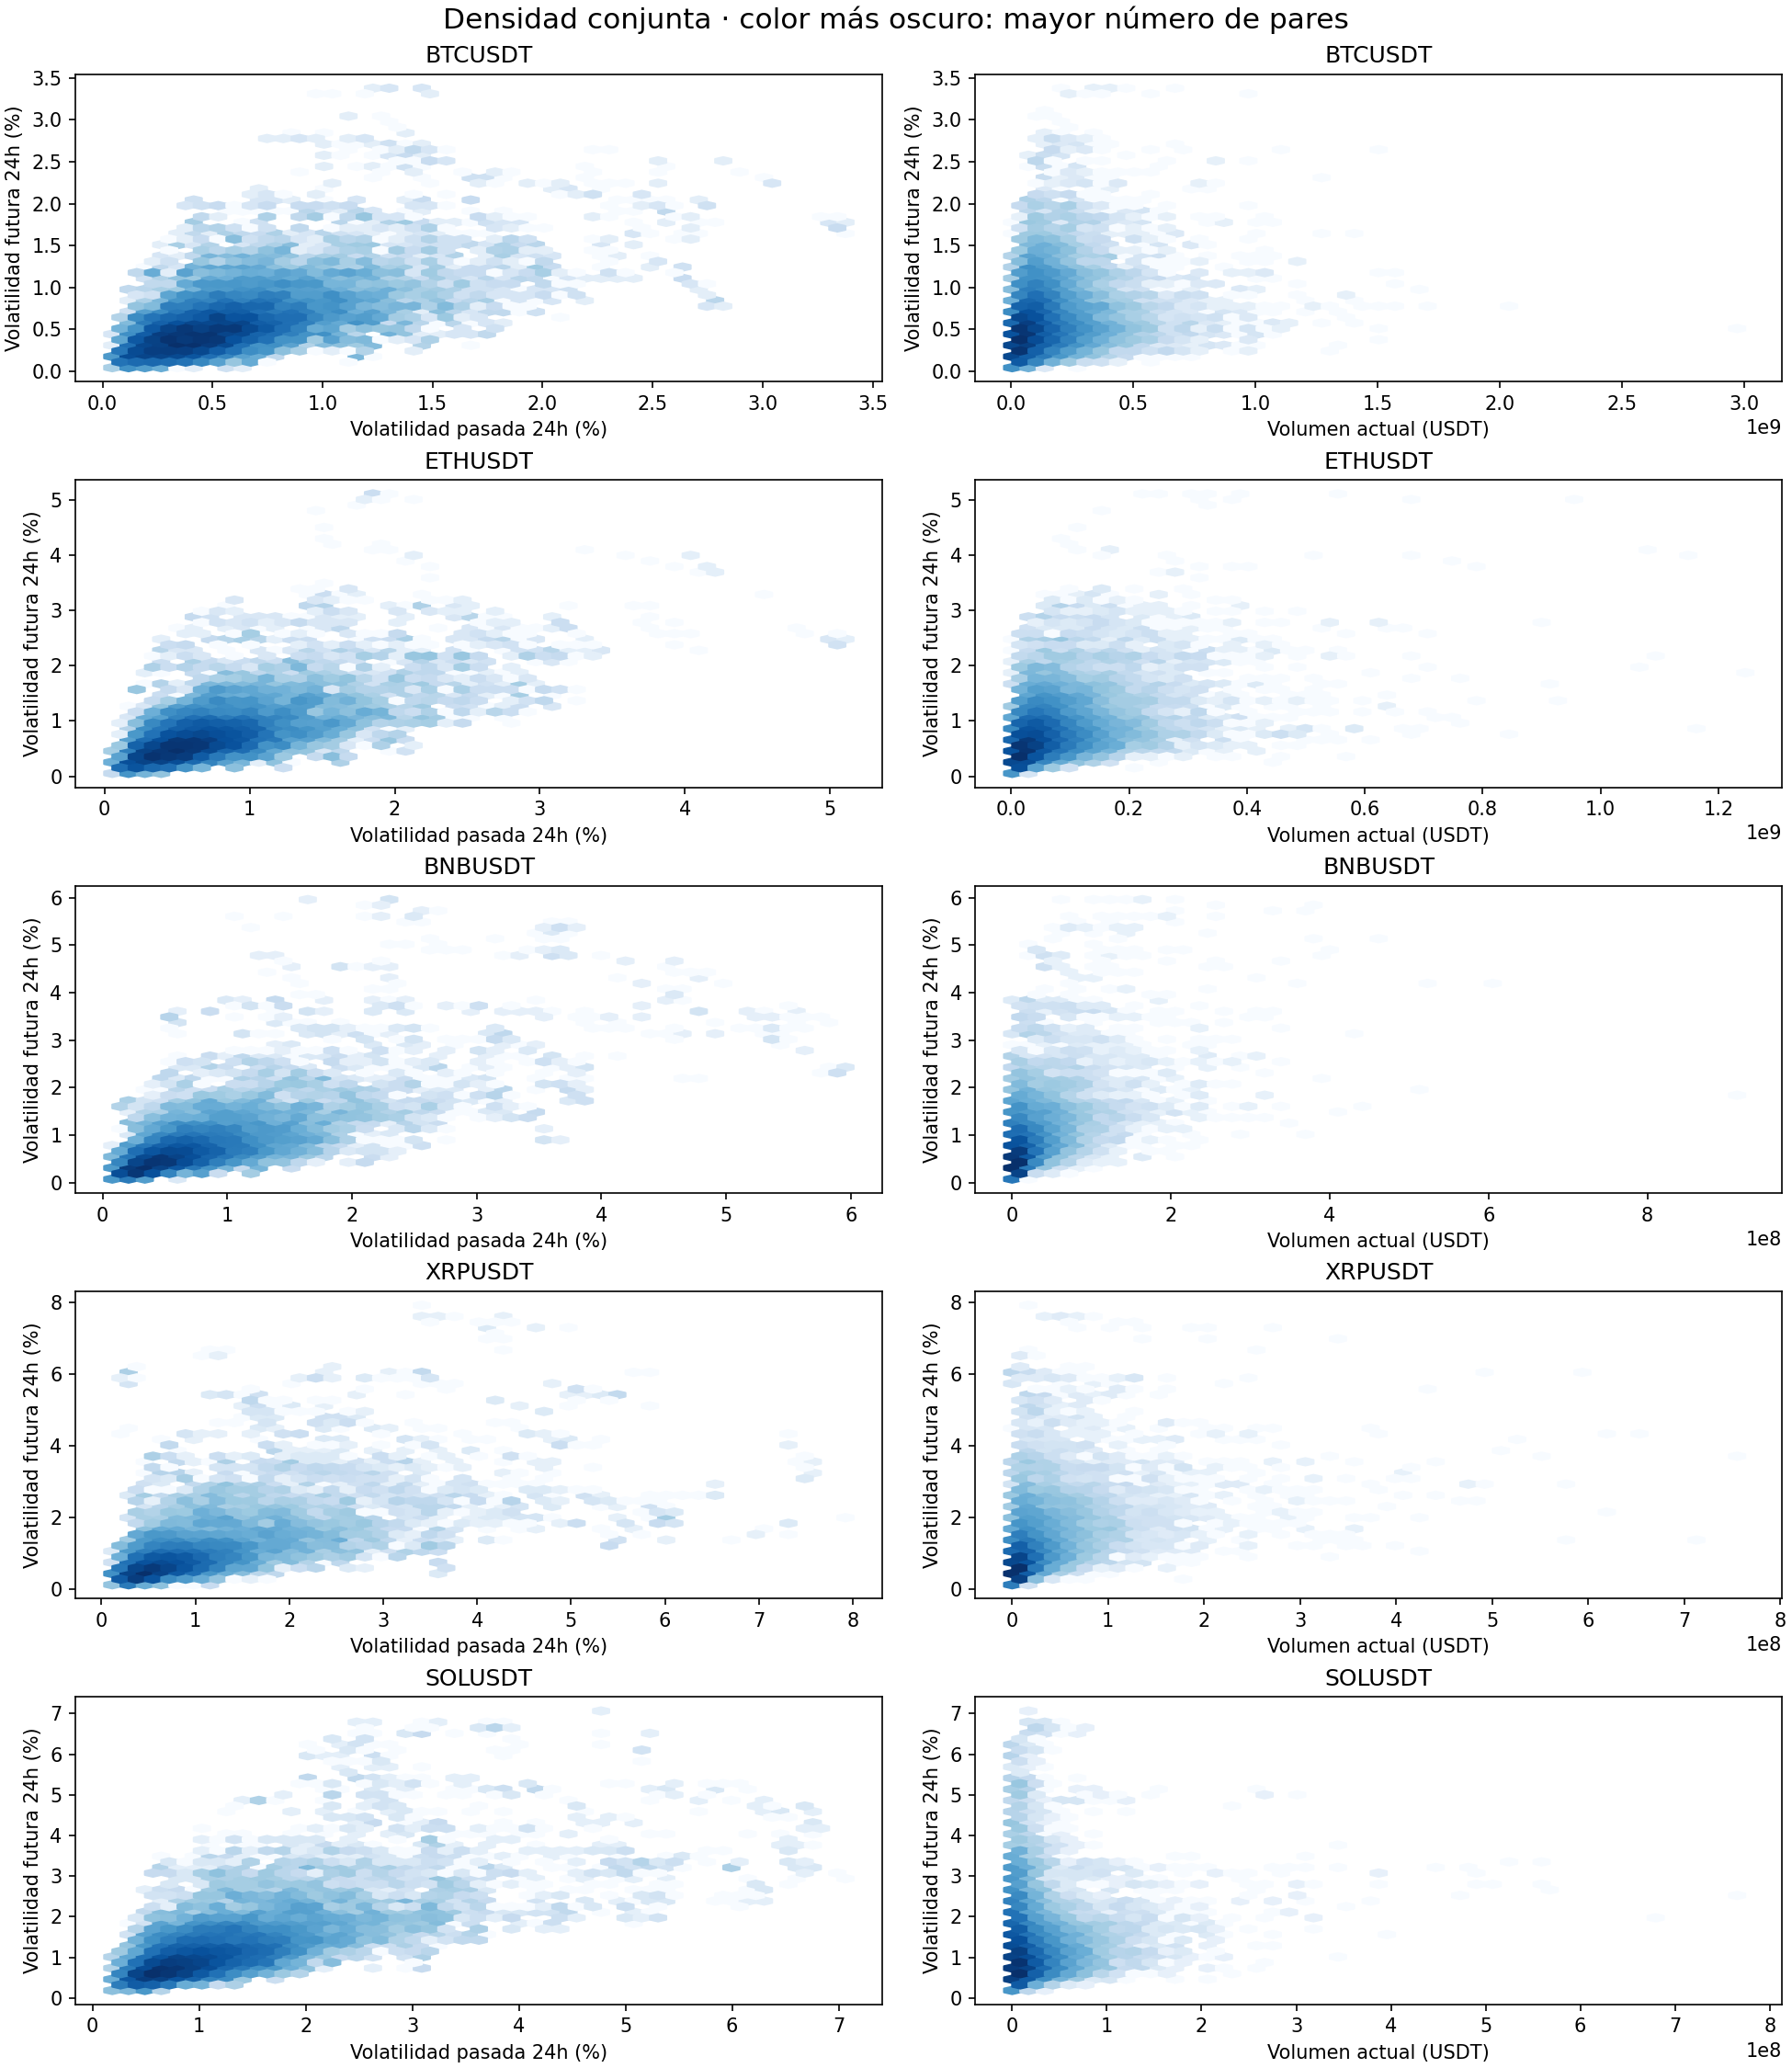

In [5]:
display(Image(filename=str(ROOT/'book/_static/figures/eda_target_relations.png')))